### 1. Convert the Llama model implementation step by step

* If you are new to implementing LLM architectures, I recommend starting with chapter 4, which walks you through the implementation of the original GPT architecture step by step
* The Converting a From-Scratch GPT Architecture to Llama 2 then implements the Llama-specific components, such as RMSNorm layers, SiLU and SwiGLU activations, RoPE (rotary position embeddings), and the SentencePiece tokenizer
* This notebook takes the Llama 2 architecture and transforms it into Llama 3 architecture by
    * modifying the rotary embeddings
    * implementing grouped-query attention
    * and using a customized version of the GPT-4 tokenizer
* Later, we then load the original Llama 3 weights shared by Meta AI into the architecture



In [3]:
import os
import sys
import io
import nbformat
import types

def import_from_notebook():
    def import_definitions_from_notebook(fullname, names):
        current_dir = os.getcwd()
        path = os.path.join(current_dir, fullname + '.ipynb')
        path = os.path.normpath(path)

        # Load the notebook
        if not os.path.exists(path):
            raise FileNotFoundError(f'Notebook file not found at: {path}')

        with io.open(path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)

        # Create a module to store the imported functions and classes
        mod = types.ModuleType(fullname)
        sys.modules[fullname] = mod

        # Go through the notebook cells and only execute function or class definitions
        for cell in nb.cells:
            if cell.cell_type == 'code':
                cell_code = cell.source
                for name in names:
                    # Check for function or class definitions
                    if f'def {name}' in cell_code or f'class {name}' in cell_code:
                        exec(cell_code, mod.__dict__)
        return mod

    fullname = 'converting-gpt-to-llama2'
    names = ["precompute_rope_params", "compute_rope", "SiLU", "FeedForward", "RMSNorm", "MultiHeadAttention"]

    return import_definitions_from_notebook(fullname, names)

In [4]:
imported_module = import_from_notebook()

# We need to redefine precompute_rope_params
# precompute_rope_params = getattr(imported_module, 'precompute_rope_params', None)
compute_rope = getattr(imported_module, 'compute_rope', None)
SiLU = getattr(imported_module, 'SiLU', None)
FeedForward = getattr(imported_module, 'FeedForward', None)
RMSNorm = getattr(imported_module, 'RMSNorm', None)

# MultiHeadAttention only for comparison purposes
MultiHeadAttention = getattr(imported_module, 'MultiHeadAttention', None)

### 1.2 Modified RoPE


    Llama 3 uses rotary position embeddings (RoPE) similar to Llama 2 (for a detailed explanation, please see the RoPE paper)
    There are some subtle differences in the RoPE settings, though
    Llama 3 now supports up to 8,192 tokens, twice as many as Llama 2 (4,096)
    The base value for the so-called RoPE (see equation below) was increased from 10,000 (Llama 2) to 500,000 (Llama 3) in the following equation (adapted from the RoPE paper)

    These values are a set of predefined parameters that are used to determine the rotational angles in the rotary matrix, where is the dimensionality of the embedding space
    Increasing the base from 10,000 to 500,000 makes the frequencies decay faster across the dimensions, which means that the higher-dimensional components are associated with smaller rotation angles than before, so the overall frequency range becomes more compressed rather than expanded


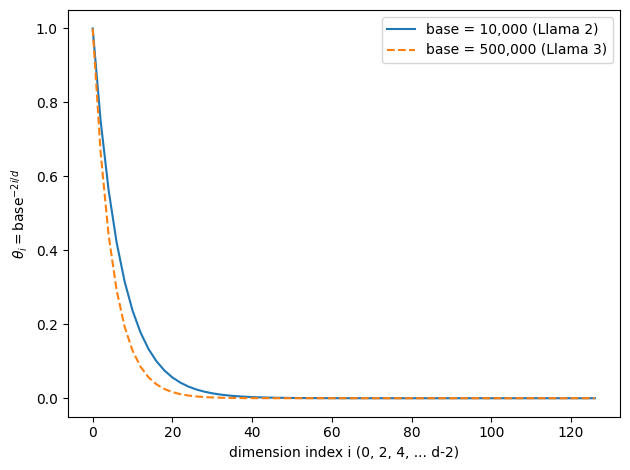

In [5]:
import matplotlib.pyplot as plt
import torch

d = 128
i = torch.arange(0, d, 2)

base_llama2 = 10_000
base_llama3 = 500_000

theta_llama2 = base_llama2 ** (-2 * i / d)
theta_llama3 = base_llama3 ** (-2 * i / d)

plt.plot(i, theta_llama2, label='base = 10,000 (Llama 2)')
plt.plot(i, theta_llama3, label='base = 500,000 (Llama 3)', ls='--')
plt.xlabel('dimension index i (0, 2, 4, ... d-2)')
plt.ylabel(r"$\theta_i = \mathrm{base}^{-2i/d}$")
plt.legend()
plt.tight_layout()


This changed decay rate is to better support longer context lengths without the rotations becoming too much or too strong at higher dimensions (larger positions)
In addition, we introduce a freq_config section in the code below that adjusts the frequency; however, we won't be needing it in Llama 3 (only Llama 3.1 and Llama 3.2), so we will revisit this freq_config later (it's set to None and ignored by default)

In [6]:
import torch

def precompute_rope_params(head_dim, theta_base=10_000, context_length=4096, freq_config=None):
    assert head_dim % 2 == 0, 'Embedding dimension must be even'

    # Compute the inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))

    # Frequency adjustments
    if freq_config is not None:
        low_freq_wavelen = freq_config['original_context_length'] / freq_config['low_freq_factor']
        high_freq_wavelen = freq_config['original_context_length'] / freq_config['high_freq_factor']

        wavelen = 2 * torch.pi / inv_freq

        inv_freq_llama = torch.where(
            wavelen > low_freq_wavelen, inv_freq / freq_config['factor'], inv_freq
        )

        smooth_factor = (freq_config['original_context_length'] / wavelen - freq_config['low_freq_factor']) / (
            freq_config['high_freq_factor'] - freq_config['low_freq_factor']
        )

        smoothed_inv_freq = (
            (1 - smooth_factor) * (inv_freq / freq_config['factor']) + smooth_factor * inv_freq
        )

        is_medium_freq = (wavelen <= low_freq_wavelen) & (wavelen >= high_freq_wavelen)
        inv_freq_llama = torch.where(is_medium_freq, smoothed_inv_freq, inv_freq_llama)
        inv_freq = inv_freq_llama

    # Generate position indices
    positions = torch.arange(context_length)

    # Compute the angles
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)     # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)     # Shape: (context_length, head_dim)

    # Precompute: sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin


* To summarize, what's new so far for Llama 3 compared to Llama 2 are the context length and theta base parameter:

In [7]:
# Instantiate RoPE parameters

llama_2_context_len = 4096
llama_3_context_len = 8192

llama_2_theta_base = 10_000
llama_3_theta_base = 500_000

* The usage remains the same as before in Llama 2:

In [8]:
# Settings
batch_size = 2
num_heads = 4
head_dim = 16

# Instantiate RoPE parameters
cos, sin = precompute_rope_params(
    head_dim=head_dim,
    theta_base=llama_3_theta_base,
    context_length=llama_3_context_len
)

# Dummy query and key tensors
torch.manual_seed(123)
queries = torch.randn(batch_size, num_heads, llama_3_context_len, head_dim)
keys = torch.randn(batch_size, num_heads, llama_3_context_len, head_dim)

# Apply rotary position embeddings
queries_rot = compute_rope(queries, cos, sin)
keys_rot = compute_rope(keys, cos, sin)

### 1.3 Grouped-query attention

* In this section, we replace multi-head attention (MHA) with an alternative mechanism called grouped-query attention (GQA)
* In short, one can think of GQA as a more compute- and parameter-efficient version of MHA
* In GQA, we reduce the number of key and value projections by sharing them among multiple attention heads
* Each attention head still has its unique query, but these queries attend to the same group of keys and values
* Below is an illustration of GQA with 2 key-value-groups (kv-groups):


* The main idea behind GQA is to reduce the number of unique query groups that attend to the key-value pairs, reducing the size of some of the matrix multiplications and the number of parameters in MHA without significantly reducing modeling performance
* The GQA code is very similar to MHA (I highlighted the changes below via the "NEW" sections)
* In short, the main change in GQA is that each query group needs to be repeated to match the number of heads it is associated with, as implemented below

* We also redesign the attention class a bit so it receives the mask through its forward method instead of storing and accessing it as self.mask. This lets us build the mask on the fly to reduce memory usage. To foreshadow why: Llama 3.1 can handle sequences of up to 128 k tokens, and precomputing a 128 k × 128 k causal mask would be extremely memory‑intensive, so we avoid it unless absolutely necessary.



In [9]:
import torch.nn as nn

class GroupedQueryAttention(nn.Module):

    def __init__(
            self, d_in, d_out, num_heads,
            num_kv_groups,
            dtype=None
    ):
        super().__init__()
        assert d_out % num_heads == 0, 'd_out must be divisible by num_heads'
        assert num_heads % num_kv_groups == 0, 'num_heads must be divisible by num_kv_groups'

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        # self.W_key = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        # self.W_value = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups

        self.W_query = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(d_out, d_out, bias=False, dtype=dtype)

    def forward(self, x, mask=None, cos=None, sin=None):
        # The forward method now accepts 'mask' instead of accessing it via self.mask
        # Also, we now have cos and sin as input for RoPE
        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)       # Shape: (b, num_tokens, d_out)
        keys = self.W_key(x)            # Shape: (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)        # Shape: (b, num_tokens, num_kv_groups * head_dim)

        # Reshape queries, keys and values
        queries = queries.reshape(b, num_tokens, self.num_heads, self.head_dim)

        # keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        # values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.reshape(b, num_tokens, self.num_kv_groups, self.head_dim)
        values = values.reshape(b, num_tokens, self.num_kv_groups, self.head_dim)

        # Transpose keys, values and queries
        keys = keys.transpose(1, 2)     # Shape: (b, num_kv_groups, num_tokens, head_dim)
        values = values.transpose(1, 2)     # Shape: (b, num_kv_groups, num_tokens, head_dim)
        queries = queries.transpose(1, 2)       # Shape: (b, num_heads, num_tokens, head_dim)

        # Apply RoPE
        if cos is not None:
            keys = compute_rope(keys, cos, sin)
            queries = compute_rope(queries, cos, sin)

        # Expand keys and values to match the number of heads
        # Shape: (b, num_heads, num_tokens, head_dim)

        keys = keys.repeat_interleave(self.group_size, dim=1)   # Shape: (b, num_heads, num_tokens, head_dim)
        values = values.repeat_interleave(self.group_size, dim=1)   # Shape: (b, num_heads, num_tokens, head_dim)
        # For example, before repeat_interleave along dim=1 (query groups):
        #   [K1, K2]
        # After repeat_interleave (each query group is repeated group_size times):
        #   [K1, K1, K2, K2]
        # If we used regular repeat instead of repeat_interleave, we'd get:
        #   [K1, K2, K1, K2]

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        # Shape: (b, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)    # Dot product for each head

        # Create mask on the fly
        if mask is None:
            mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask, -torch.inf)

        assert keys.shape[-1] == self.head_dim
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)    # optional projection

        return context_vec

* To illustrate the parameter savings in GQA over MHA, consider the following multi-head attention example from the GPT and Llama 2 code:

In [10]:
# Settings
batch_size = 1
context_len = 3000
max_content_len = 8192
embed_dim = 4096
num_heads = 32

example_batch = torch.randn((batch_size, context_len, embed_dim))

mha = MultiHeadAttention(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=max_content_len,
    num_heads=num_heads
)

mha(example_batch)

print('W_key:', mha.W_key.weight.shape)
print('W_value:', mha.W_value.weight.shape)
print('W_query:', mha.W_query.weight.shape)

W_key: torch.Size([4096, 4096])
W_value: torch.Size([4096, 4096])
W_query: torch.Size([4096, 4096])


* Now, if we use grouped-query attention instead, with 8 kv-groups (that's how many Llama 3 8B uses), we can see that the number of rows of the key and value matrices are reduced by a factor of 4 (because 32 attention heads divided by 8 kv-groups is 4)

In [11]:
gqa = GroupedQueryAttention(
    d_in=embed_dim,
    d_out=embed_dim,
    num_heads=num_heads,
    num_kv_groups=8,
)

gqa(example_batch)

print('W_key:', gqa.W_key.weight.shape)
print('W_value:', gqa.W_value.weight.shape)
print('W_query:', gqa.W_query.weight.shape)

W_key: torch.Size([1024, 4096])
W_value: torch.Size([1024, 4096])
W_query: torch.Size([4096, 4096])


* As a side note, to make the GroupedQueryAttention equivalent to standard multi-head attention, you can set the number of query groups (num_kv_groups) equal to the number of heads (num_heads)
* Lastly, let's compare the number of parameters below:

In [12]:
print('Total number of parameters:')

mha_total_params = sum(p.numel() for p in mha.parameters())
print(f'MHA: {mha_total_params:,}')

gqa_total_params = sum(p.numel() for p in gqa.parameters())
print(f'GQA: {gqa_total_params:,}')

Total number of parameters:
MHA: 67,108,864
GQA: 41,943,040


In [13]:
# Free up memory
del mha
del gqa

### 1.4 Update the TransformerBlock module

* Next, we update the TransformerBlock
* Here, we simply swap MultiHeadAttention with GroupedQueryAttention and add the new RoPE settings
* In addition, we also modify the forward method so that it receives mask, cos, and sin; since the values for those are the same for each transformer block, we only have to compute them once and then can reuse them

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = GroupedQueryAttention(
            d_in=cfg['emb_dim'],
            d_out=cfg['emb_dim'],
            num_heads=cfg['n_heads'],
            num_kv_groups=cfg['n_kv_groups'],
            dtype=cfg['dtype']
        )
        self.ff = FeedForward(cfg)
        self.norm1 = RMSNorm(cfg['emb_dim'], eps=1e-5)
        self.norm2 = RMSNorm(cfg['emb_dim'], eps=1e-5)
        self.dtype = cfg['dtype']

    def forward(self, x, mask=None, cos=None, sin=None):
        # The forward method now accepts 'mask' instead of accessing it via self.mask
        # Also, we now have cos and sin as input for RoPE
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x.to(self.dtype), mask, cos, sin)  # Shape [batch_size, num_tokens, emb_size]
        x = x + shortcut    # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x.to(self.dtype))
        x = x + shortcut    # Add the original input back

        return x

### 1.5 Defining the model class

* When setting up the model class, we technically don't have to do much; we just update the name to Llama3Model
* However, since we now pass the mask, cos, and sin to the transformer blocks, we also have to add them here



In [15]:
class Llama3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'], dtype=cfg['dtype'])

        self.trf_blocks = nn.ModuleList(
            [TransformerBlock(cfg) for _ in range(cfg['n_layers'])])

        self.final_norm = RMSNorm(cfg['emb_dim'], eps=1e-5)
        self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False, dtype=cfg['dtype'])

        cos, sin = precompute_rope_params(
            head_dim=cfg['emb_dim'] // cfg['n_heads'],
            theta_base=cfg['rope_base'],
            context_length=cfg['context_length'],
            freq_config=cfg['rope_freq']
        )

        self.register_buffer('cos', cos, persistent=False)
        self.register_buffer('sin', sin, persistent=False)

        self.cfg = cfg

    def forward(self, in_idx):
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds

        num_tokens = x.shape[1]
        mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)

        for block in self.trf_blocks:
            x = block(x, mask, self.cos, self.sin)
        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg['dtype']))
        return logits

### 2. Initialize model

* Now we can define a Llama 3 config file (the Llama 2 config file is shown for comparison)



In [16]:
LLAMA2_CONFIG_7B = {
    "vocab_size": 32_000,    # Vocabulary size
    "context_length": 4096,  # Context length
    "emb_dim": 4096,         # Embedding dimension
    "n_heads": 32,           # Number of attention heads
    "n_layers": 32,          # Number of layers
    "hidden_dim": 11_008,    # Size of the intermediate dimension in FeedForward
    "dtype": torch.bfloat16  # Lower-precision dtype to reduce memory usage
}

In [17]:
LLAMA3_CONFIG_8B = {
    "vocab_size": 128_256,   # NEW: Larger vocabulary size
    "context_length": 8192,  # NEW: Larger context length
    "emb_dim": 4096,         # Embedding dimension
    "n_heads": 32,           # Number of attention heads
    "n_layers": 32,          # Number of layers
    "hidden_dim": 14_336,    # NEW: Larger size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,        # NEW: Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,  # NEW: The base in RoPE's "theta" was increased to 500_000
    "rope_freq": None,       # NEW: Additional configuration for adjusting the RoPE frequencies
    "dtype": torch.bfloat16  # Lower-precision dtype to reduce memory usage
}

* Using these settings, we can now initialize a Llama 3 8B model
* Note that this requires ~34 GB of memory (for comparison, Llama 2 7B required ~26 GB of memory)

In [18]:
model = Llama3Model(LLAMA3_CONFIG_8B)

KeyboardInterrupt: 

* Let's now compute the number of trainable parameters:

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

* As shown above, the model contains 8 billion parameters
* Additionally, we can calculate the memory requirements for this model using the code below:

In [ ]:
def calc_model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024 ** 3)

    return total_memory_gb

print(f"float32 (PyTorch default): {calc_model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {calc_model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device);


### 3. Load tokenizer

* In this section, we are going to load the tokenizer for the model
Llama 2 used Google's SentencePiece tokenizer instead of OpenAI's BPE tokenizer based on the Tiktoken library
* Llama 3, however, reverted back to using the BPE tokenizer from Tiktoken; specifically, it uses the GPT-4 tokenizer with an extended vocabulary
* You can find the original Tiktoken-adaptation by Meta AI here in their official Llama 3 repository
* Below, I rewrote the tokenizer code to make it more readable and minimal for this notebook (but the behavior should be similar)



In [ ]:
from pathlib import Path

import tiktoken
from tiktoken.load import load_tiktoken_bpe


class Tokenizer:
    """Thin wrapper around tiktoken that keeps track of Llama-3 special IDs."""
    def __init__(self, model_path):
        if not os.path.isfile(model_path):
            raise FileNotFoundError(model_path)

        mergeable = load_tiktoken_bpe(model_path)

        # hard-coded from Meta's tokenizer.json
        self.special = {
            "<|begin_of_text|>": 128000,
            "<|end_of_text|>": 128001,
            "<|start_header_id|>": 128006,
            "<|end_header_id|>": 128007,
            "<|eot_id|>": 128009,
        }
        self.special.update({f"<|reserved_{i}|>": 128002 + i
                             for i in range(256)
                             if 128002 + i not in self.special.values()})

        self.model = tiktoken.Encoding(
            name=Path(model_path).name,
            pat_str=r"(?i:'s|'t|'re|'ve|'m|'ll|'d)"
                    r"|[^\r\n\p{L}\p{N}]?\p{L}+"
                    r"|\p{N}{1,3}"
                    r"| ?[^\s\p{L}\p{N}]+[\r\n]*"
                    r"|\s*[\r\n]+"
                    r"|\s+(?!\S)"
                    r"|\s+",
            mergeable_ranks=mergeable,
            special_tokens=self.special,
        )

    def encode(self, text, bos=False, eos=False):
        ids = ([self.special["<|begin_of_text|>"]] if bos else []) \
              + self.model.encode(text)
        if eos:
            ids.append(self.special["<|end_of_text|>"])
        return ids

    def decode(self, ids):
        return self.model.decode(ids)



* Meta AI shared the original Llama 3 model weights and tokenizer vocabulary on the Hugging Face Hub
* We will first download the tokenizer vocabulary from the Hub and load it into the code above

In [ ]:
from huggingface_hub import login
import json

with open("config.json", "r") as config_file:
    config = json.load(config_file)
    access_token = config["HF_ACCESS_TOKEN"]

login(token=access_token)


In [ ]:
from huggingface_hub import hf_hub_download

tokenizer_file_path = hf_hub_download(
    repo_id="meta-llama/Meta-Llama-3-8B",
    filename="original/tokenizer.model",
    local_dir="Llama-3-8B"
)

In [ ]:
tokenizer = Tokenizer(tokenizer_file_path)

In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New: numerical stability tip to get equivalent results
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)   # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)      # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)   # (batch_size, 1)

        if eos_id is not None and (idx_next == eos_id).any():  # Stop generating early if end-of-sequence token is encountered
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)     # (batch_size, num_tokens + 1)
    return idx

In [ ]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)     # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)     # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=30,
    context_size=LLAMA3_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))



### 4. Load pretrained weights

* We are loading the "meta-llama/Meta-Llama-3-8B" base model below, which is a simple text completion model before finetuning
* Alternatively, you can load the instruction-finetuned and aligned "meta-llama/* * * * Meta-Llama-3-8B-Instruct" model by modifying the string in the next code cell accordingly
* Combined, the weight files are about 16 GB large



In [ ]:
from safetensors.torch import load_file

combined_weights = {}

for i in range(1, 5):
    weights_file = hf_hub_download(
        repo_id="meta-llama/Meta-Llama-3-8B",
        filename=f"model-0000{i}-of-00004.safetensors",
        local_dir="Llama-3-8B"
    )
    current_weights = load_file(weights_file)
    combined_weights.update(current_weights)

In [ ]:
list(combined_weights.keys())[:15]

In [ ]:
def assign(left, right, tensor_name="unknown"):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

    with torch.no_grad():
        if isinstance(right, torch.Tensor):
            left.copy_(right)
        else:
            left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

    return left


def load_weights_into_llama(model, param_config, params):
    model.tok_emb.weight = assign(model.tok_emb.weight, params["model.embed_tokens.weight"], "model.embed_tokens.weight")

    for l in range(param_config["n_layers"]):

        # Load attention weights
        model.trf_blocks[l].att.W_query.weight = assign(
            model.trf_blocks[l].att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        model.trf_blocks[l].att.W_key.weight = assign(
            model.trf_blocks[l].att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        model.trf_blocks[l].att.W_value.weight = assign(
            model.trf_blocks[l].att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )
        model.trf_blocks[l].att.out_proj.weight = assign(
            model.trf_blocks[l].att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )
        model.trf_blocks[l].norm1.weight = assign(
            model.trf_blocks[l].norm1.weight,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Load FeedForward weights
        model.trf_blocks[l].ff.fc1.weight = assign(
            model.trf_blocks[l].ff.fc1.weight,
            params[f"model.layers.{l}.mlp.gate_proj.weight"],
            f"model.layers.{l}.mlp.gate_proj.weight"
        )
        model.trf_blocks[l].ff.fc2.weight = assign(
            model.trf_blocks[l].ff.fc2.weight,
            params[f"model.layers.{l}.mlp.up_proj.weight"],
            f"model.layers.{l}.mlp.up_proj.weight"
        )
        model.trf_blocks[l].ff.fc3.weight = assign(
            model.trf_blocks[l].ff.fc3.weight,
            params[f"model.layers.{l}.mlp.down_proj.weight"],
            f"model.layers.{l}.mlp.down_proj.weight"
        )
        model.trf_blocks[l].norm2.weight = assign(
            model.trf_blocks[l].norm2.weight,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Load output layer weights
    model.final_norm.weight = assign(model.final_norm.weight, params["model.norm.weight"], "model.norm.weight")

    if "lm_head.weight" in params.keys():
        model.out_head.weight = assign(model.out_head.weight, params["lm_head.weight"], "lm_head.weight")
    else:
        model.out_head.weight = model.tok_emb.weight
        print("Model uses weight tying.")


load_weights_into_llama(model, LLAMA3_CONFIG_8B, combined_weights)
model.to(device);
del combined_weights  # free up memory

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA3_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

### 5. Using the instruction-finetuned model

* Above, we used the pretrained base model; if you want to use a model capable of following instructions, use the "meta-llama/Llama-3-8B-Instruct" model instead, as shown below



In [ ]:
# to free up memory

import gc

del model

gc.collect()  # Run Python garbage collector

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
combined_weights = {}

for i in range(1, 5):
    weights_file = hf_hub_download(
        repo_id="meta-llama/Meta-Llama-3-8B-Instruct",
        filename=f"model-0000{i}-of-00004.safetensors",
        local_dir="Llama-3-8B-Instruct"
    )
    current_weights = load_file(weights_file)
    combined_weights.update(current_weights)


model = Llama3Model(LLAMA3_CONFIG_8B)
load_weights_into_llama(model, LLAMA3_CONFIG_8B, combined_weights)
model.to(device)
del combined_weights  # free up memory


In [ ]:
class ChatFormat:

    def __init__(self, tokenizer: Tokenizer, *,
                 default_system="You are a helpful assistant."):
        self.tok = tokenizer
        self.default_system = default_system

    def _header(self, role):
        """Encode <|start_header_id|>role<|end_header_id|>\n\n"""
        return (
            [self.tok.special["<|start_header_id|>"]]
            + self.tok.encode(role)
            + [self.tok.special["<|end_header_id|>"]]
            + self.tok.encode("\n\n")
        )

    def encode(self, user_message, system_message=None):
        sys_msg = system_message if system_message is not None else self.default_system

        ids = [self.tok.special["<|begin_of_text|>"]]

        # system
        ids += self._header("system")
        ids += self.tok.encode(sys_msg)
        ids += [self.tok.special["<|eot_id|>"]]

        # user
        ids += self._header("user")
        ids += self.tok.encode(user_message)
        ids += [self.tok.special["<|eot_id|>"]]

        # assistant header (no content yet)
        ids += self._header("assistant")

        return ids

In [ ]:
tokenizer = Tokenizer(tokenizer_file_path)
chat_tokenizer = ChatFormat(tokenizer)

token_ids = chat_tokenizer.encode("Hello World!")
print(token_ids)

In [ ]:
tokenizer.decode(token_ids)

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("What do llamas eat?", chat_tokenizer).to(device),
    max_new_tokens=150,
    context_size=LLAMA3_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

output_text = token_ids_to_text(token_ids, tokenizer)


def clean_text(text, header_end="assistant<|end_header_id|>\n\n"):
    # Find the index of the first occurrence of "<|end_header_id|>"
    index = text.find(header_end)

    if index != -1:
        # Return the substring starting after "<|end_header_id|>"
        return text[index + len(header_end):].strip()  # Strip removes leading/trailing whitespace
    else:
        # If the token is not found, return the original text
        return text

print("Output text:\n", clean_text(output_text))

### 6. Llama 3.1 8B

* A few months after the initial Llama 3 release, Meta AI followed up with their Llama 3.1 suite of models (see the official Introducing Llama 3.1: Our most capable models to date announcement blog post for details)
* Conveniently, we can reuse our previous Llama 3 code from above to implement Llama 3.1 8B



In [ ]:
LLAMA3_CONFIG_8B = {
    "vocab_size": 128_256,   # Vocabulary size
    "context_length": 8192,  # Context length
    "emb_dim": 4096,         # Embedding dimension
    "n_heads": 32,           # Number of attention heads
    "n_layers": 32,          # Number of layers
    "hidden_dim": 14_336,    # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,        # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,  # The base in RoPE's "theta"
    "rope_freq": None,       # Additional configuration for adjusting the RoPE frequencies
    "dtype": torch.bfloat16  # Lower-precision dtype to reduce memory usage
}

LLAMA31_CONFIG_8B = {
    "vocab_size": 128_256,      # Vocabulary size
    "context_length": 131_072,  # NEW: Larger supported context length
    "emb_dim": 4096,            # Embedding dimension
    "n_heads": 32,              # Number of attention heads
    "n_layers": 32,             # Number of layers
    "hidden_dim": 14_336,       # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,           # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,     # The base in RoPE's "theta"
    "dtype": torch.bfloat16,    # Lower-precision dtype to reduce memory usage
    "rope_freq": {              # NEW: RoPE frequency scaling
        "factor": 8.0,
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}

* As we've seen in the code earlier, the RoPE method uses sinusoidal functions (sine and cosine) to embed positional information directly into the attention mechanism
* In Llama 3.1, via the additional configuration, we introduce additional adjustments to the inverse frequency calculations
* These adjustments influence how different frequency components contribute to the positional embeddings (a detailed explanation is a topic for another time)
* Let's try out the Llama 3.1 model in practice; first, we clear out the old model to free up some GPU memory

In [ ]:
# free up memory
del model

gc.collect()  # Run Python garbage collector

if torch.cuda.is_available():
    torch.cuda.empty_cache()

* Next, we download the tokenizer
* Note that since the Llama 3.1 family is distinct from the Llama 3 family, you'd have to go to the meta-llama/Llama-3.1-8B repository and acknowledge the license terms for your Hugging Face access token to work for the download
* Tip: For simplicity, we only load the base model below, but there's also an instruction-finetuned version you can use by replacing "meta-llama/Llama-3.1-8B" with "meta-llama/Llama-3.1-8B-Instruct"

In [ ]:
tokenizer_file_path = hf_hub_download(
    repo_id="meta-llama/Llama-3.1-8B",
    filename="original/tokenizer.model",
    local_dir="Llama-3.1-8B"
)

tokenizer = Tokenizer(tokenizer_file_path)


In [ ]:
model = Llama3Model(LLAMA31_CONFIG_8B)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

In [ ]:
combined_weights = {}

for i in range(1, 5):
    weights_file = hf_hub_download(
        repo_id="meta-llama/Llama-3.1-8B",
        filename=f"model-0000{i}-of-00004.safetensors",
        local_dir="Llama-3.1-8B"
    )
    current_weights = load_file(weights_file)
    combined_weights.update(current_weights)

load_weights_into_llama(model, LLAMA31_CONFIG_8B, combined_weights)
model.to(device);
del combined_weights  # free up memory

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA31_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

### 7. Llama 3.2 1B

* As of this writing, Meta AI's latest models are the Llama 3.2 models announced here
* The code for the Llama 3.2 text model is similar to that of Llama 3.1, except that the model has shrunk in size (there is a 1B and 3B version)
* The other efficiency tweak was that they added back weight tying (a concept that was original used in the GPT-2 architecture); here, they reuse the same weight parameter values in the input (token) embedding layer and output layer
* The small model size of Llama 3.2 1B is quite convenient, since it can even run on many mobile devices
* The architectural differences between Llama 3.1 8B and Llama 3.2 1B are illustrated in the figure below
* As we can see based on the figure above, the main difference between the Llama 3.1 8B and Llama 3.2 1B architectures are the respective sizes
* A small additional change is an increased RoPE rescaling factor, which is reflected in the configuration file below

In [ ]:
LLAMA31_CONFIG_8B = {
    "vocab_size": 128_256,      # Vocabulary size
    "context_length": 131_072,  # NEW: Larger supported context length
    "emb_dim": 4096,            # Embedding dimension
    "n_heads": 32,              # Number of attention heads
    "n_layers": 32,             # Number of layers
    "hidden_dim": 14_336,       # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,           # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,     # The base in RoPE's "theta"
    "dtype": torch.bfloat16,    # Lower-precision dtype to reduce memory usage
    "rope_freq": {              # NEW: RoPE frequency scaling
        "factor": 8.0,
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}


LLAMA32_CONFIG_1B = {
    "vocab_size": 128_256,      # Vocabulary size
    "context_length": 131_072,  # Context length
    "emb_dim": 2048,            # NEW: Half the embedding dimension
    "n_heads": 32,              # Number of attention heads
    "n_layers": 16,             # NEW: Half the number of layers
    "hidden_dim": 8192,         # NEW: Almost half the size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,           # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,     # The base in RoPE's "theta"
    "dtype": torch.bfloat16,    # Lower-precision dtype to reduce memory usage
    "rope_freq": {              # RoPE frequency scaling
        "factor": 32.0,         # NEW: Adjustment of the rescaling factor
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}

In [ ]:
# free up memory
del model


gc.collect()  # Run Python garbage collector

if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [ ]:
tokenizer_file_path = hf_hub_download(
    repo_id="meta-llama/Llama-3.2-1B",
    filename="original/tokenizer.model",
    local_dir="Llama-3.2-1B"
)

tokenizer = Tokenizer(tokenizer_file_path)

In [ ]:
model = Llama3Model(LLAMA32_CONFIG_1B)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

# Account for weight tying
total_params_normalized = total_params - model.tok_emb.weight.numel()
print(f"\nTotal number of unique parameters: {total_params_normalized:,}")

In [ ]:
def count_unique_parameters(model):
    unique_params = set()
    total_unique_params = 0

    for param in model.parameters():
        if param.data_ptr() not in unique_params:
            total_unique_params += param.numel()
            unique_params.add(param.data_ptr())

    return total_unique_params

total_params_uniq = count_unique_parameters(model)
print(f"\nTotal number of unique parameters: {total_params_uniq:,}")

In [ ]:
weights_file = hf_hub_download(
    repo_id="meta-llama/Llama-3.2-1B",
    filename="model.safetensors",
    local_dir="Llama-3.2-1B"
)
current_weights = load_file(weights_file)

load_weights_into_llama(model, LLAMA32_CONFIG_1B, current_weights)
model.to(device);
del current_weights  # free up memory

In [ ]:
# Checks that the weight values are the same
print("Weight tying:", torch.equal(model.tok_emb.weight, model.out_head.weight))

In [ ]:
# Furthermore, check if PyTorch uses the same underlying memory
print("Weight tying:", model.tok_emb.weight.data_ptr() == model.out_head.weight.data_ptr())

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA32_CONFIG_1B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))